In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import WeibullFitter

In [14]:
t = np.linspace(0, 12, 100)
s_t = np.exp(-(t/3)**0.5)

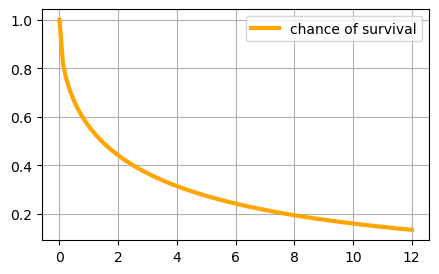

In [15]:
plt.figure(figsize=(5, 3))
plt.plot(t, s_t, label='chance of survival', color='orange', lw=3)
plt.grid()
plt.legend()
plt.show()

In [43]:
df = pd.read_csv('trendy_products.csv')
df.head(10)

,product_id,category,launch_popularity_score,influencer_push,discount_support,months_observed,outcome
0,P001,Labubus,77,1,0,9,0
1,P002,Labubus,95,0,1,12,0
2,P003,Labubus,92,1,0,14,1
3,P004,Labubus,86,1,0,17,0
4,P005,Labubus,86,1,0,9,1
5,P006,Labubus,97,1,1,11,0
6,P007,Labubus,77,1,0,11,1
7,P008,Labubus,93,1,0,12,1
8,P009,Labubus,80,1,0,11,0
9,P010,Labubus,77,1,1,11,1


In [44]:
df['category'].value_counts()

category
Labubus          20
Stanley          20
Pokemon Cards    20
Name: count, dtype: int64

In [45]:
stanley = df[df['category'] == 'Stanley']
wf_stl = WeibullFitter()
wf_stl.fit(durations = stanley['months_observed'], event_observed = stanley['outcome'],
          label = 'Stanley Cup')

<lifelines.WeibullFitter:"Stanley Cup", fitted with 20 total observations, 9 right-censored observations>

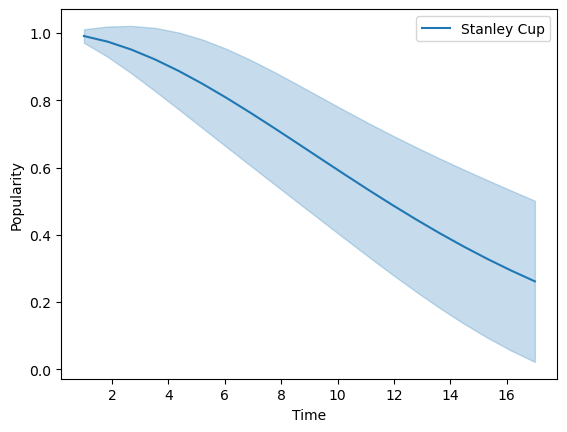

In [46]:
wf_stl.plot_survival_function(ci_show = True)
plt.ylabel('Popularity')
plt.xlabel('Time')
plt.show()

In [ ]:
labubus = df[df["category"] == "Labubus"]
wf_lbb = WeibullFitter()
wf_lbb.fit(durations=labubus["months_observed"], event_observed=labubus["outcome"],
       label="Labubus")

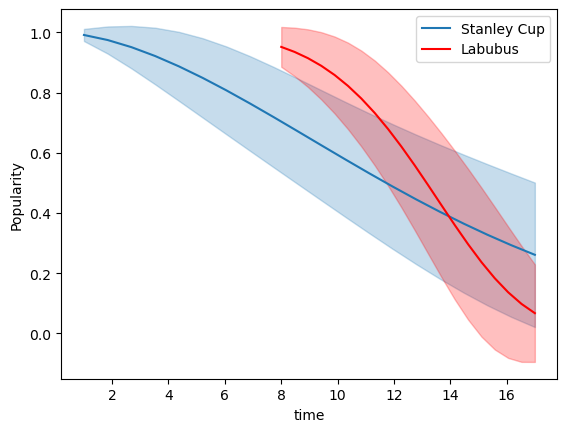

In [21]:

wf_stl.plot_survival_function(ci_show=True)
wf_lbb.plot_survival_function(ci_show=True, color='red')
plt.ylabel("Popularity")
plt.xlabel('time')
plt.show()

In [41]:
Pokemon_Cards = df[df["category"] == "Pokemon Cards"]
wf_pcb = WeibullFitter()
wf_pcb.fit(durations=labubus["months_observed"], event_observed = Pokemon_Cards["outcome"],
       label="Pokemon Cards")

<lifelines.WeibullFitter:"Pokemon Cards", fitted with 20 total observations, 6 right-censored observations>

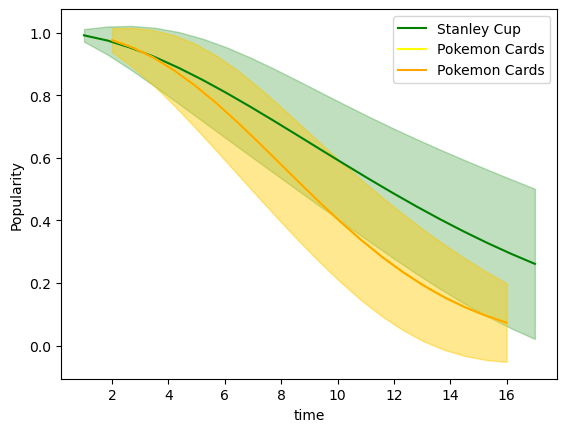

In [42]:
wf_stl.plot_survival_function(ci_show=True, color = 'green')
wf_lbb.plot_survival_function(ci_show=True, color='yellow')
wf_pcb.plot_survival_function(ci_show=True, color='orange')
plt.ylabel("Popularity")
plt.xlabel('time')
plt.show()